# Run cells from AllenDB

In [1]:
import os, sys, json
import matplotlib.pyplot as plt
import numpy as np

# Import single_cells modules
from modules import download_cell
from modules import build_cell
from modules import run_sim

# Import ACT modules
act_path = "../../mods/ACT"
if os.path.isdir(act_path):
    sys.path.append(act_path)
else:
    !pip install --upgrade pip2 > /dev/null 2>&1
    !pip install --quiet allensdk neuron > /dev/null 2>&1
    !git clone https://github.com/V-Marco/ACT.git
    sys.path.append('ACT')
from act.passive import ACTPassiveModule

--No graphics will be displayed.


# Download Cell

### Set Parameters

In [ ]:
cell_name = 'SST'
cell_dir = f"cells/{cell_name}"
if os.path.isdir(cell_dir): os.chdir(cell_dir)
# else:


# http://celltypes.brain-map.org/mouse/experiment/electrophysiology/'specimen_id'
specimen_id = 476686112 #SST 476686112, SST2 485466109, PV 484635029, 571709783
model_type = 'perisomatic' #or 'all active'

tunes_dir = 'tunes'
model_dir = f'OriginalFromAllenDB/{specimen_id}_{model_type}' # or None=tunes_dir

### Download Cell (if not already downloaded)

In [3]:
# (Optional) list available bundles for a specimen
download_cell.list_ADB_models(specimen_id)                             # all
download_cell.list_ADB_models(specimen_id, filter_type=model_type)  # filtered

# Download a bundle
cell_info = download_cell.download_ADB_cell(
    specimen_id=specimen_id,
    model_type=model_type,          # or "all active"
    tunes_dir=tunes_dir,    # base dir
    cache_stimulus=False,              # skip big NWB
    subdir=model_dir,          # None ='tunes_dir/', else ='tunes_dir'/'model_dir/'
    match="contains",                  # name matching behavior
    quiet=False,
)
cell_info["model_id"], cell_info["model_name"], cell_info["tunes_dir"]

# List the files you just pulled
len(cell_info["files"]), cell_info["files"][:5]

Models for specimen_id=476686112:
  477878284  Biophysical - perisomatic_Sst-IRES-Cre;Ai14-188740.03.02.01
  497232660  Biophysical - all active_Sst-IRES-Cre;Ai14-188740.03.02.01
Models for specimen_id=476686112:
  477878284  Biophysical - perisomatic_Sst-IRES-Cre;Ai14-188740.03.02.01
[download_ADB_cell] Found existing cache at: tunes/OriginalFromAllenDB/476686112_perisomatic — skipping download.


(59,
 ['tunes/OriginalFromAllenDB/476686112_perisomatic/476686112_fit.json',
  'tunes/OriginalFromAllenDB/476686112_perisomatic/Sst-IRES-Cre_Ai14-188740.03.02.01_657210399_m.marker',
  'tunes/OriginalFromAllenDB/476686112_perisomatic/Sst-IRES-Cre_Ai14-188740.03.02.01_657210399_m.swc',
  'tunes/OriginalFromAllenDB/476686112_perisomatic/manifest.json',
  'tunes/OriginalFromAllenDB/476686112_perisomatic/modfiles/CaDynamics.mod'])

### Compile Modfiles

In [4]:
os.chdir(f'{tunes_dir}/{model_dir}')

# update_modfiles = None # or path/link to modfiles TODO
# if update_modfiles is not None:
#     !git clone update_modfiles

# if already compiled then lets delete the folder and force a recompile
if os.path.isdir('modfiles/x86_64'):
    os.system("rm -rf modfiles/x86_64")
# compile the mod files
if not os.path.isdir("modfiles/x86_64"):
    # !nrnivmodl modfiles > /dev/null 2>&1
    os.chdir('modfiles')
    os.system("nrnivmodl")
    os.chdir("..")


from neuron import h
h.load_file("stdrun.hoc")  # Required to use h.run()
h.nrn_load_dll("modfiles/x86_64/.libs/libnrnmech.so")

/home/hrbncv/PV-SST/single_cells/cells/SST/tunes/OriginalFromAllenDB/476686112_perisomatic/modfiles
Mod files: "./CaDynamics.mod" "./Ca_HVA.mod" "./Ca_LVA.mod" "./Ih.mod" "./Im.mod" "./Im_v2.mod" "./Kd.mod" "./K_P.mod" "./K_T.mod" "./Kv2like.mod" "./Kv3_1.mod" "./Nap.mod" "./NaTa.mod" "./NaTs.mod" "./NaV.mod" "./SK.mod"

Creating 'x86_64' directory for .o files.

 -> Compiling mod_func.cpp
 -> NMODL ../CaDynamics.mod
 -> NMODL ../Ca_HVA.mod
 -> NMODL ../Ca_LVA.mod


/home/hrbncv/miniconda3/envs/BMTK/bin/nrnivmodl:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
Translating CaDynamics.mod into /home/hrbncv/PV-SST/single_cells/cells/SST/tunes/OriginalFromAllenDB/476686112_perisomatic/modfiles/x86_64/CaDynamics.c
Translating Ca_HVA.mod into /home/hrbncv/PV-SST/single_cells/cells/SST/tunes/OriginalFromAllenDB/476686112_perisomatic/modfiles/x86_64/Ca_HVA.c
Thread Safe
Translating Ca_LVA.mod into /home/hrbncv/PV-SST/single_cells/cells/SST/tunes/OriginalFromAllenDB/476686112_perisomatic/modfiles/x86_64/Ca_LVA.c
Thread Safe
Thread Safe
Translating Ih.mod into /home/hrbncv/PV-SST/single_cells/cells/SST/tunes/OriginalFromAllenDB/476686112_perisomatic/modfiles/x86_64/Ih.c
Thread Safe
Translating Im.mod into /home/hrbncv/PV-SST/single_cells/cells/SST/tunes/OriginalFromAllenDB/476686112_perisomatic/modfiles/x86_64/Im.c
Translating Im_v2.mod into /h

 -> NMODL ../Ih.mod
 -> NMODL ../Im.mod
 -> NMODL ../Im_v2.mod
 -> NMODL ../Kd.mod
 -> NMODL ../K_P.mod
 -> NMODL ../K_T.mod
 -> NMODL ../Kv2like.mod
 -> NMODL ../Kv3_1.mod
 -> NMODL ../Nap.mod
 -> NMODL ../NaTa.mod
 -> NMODL ../NaTs.mod
 -> NMODL ../NaV.mod
 -> NMODL ../SK.mod
 -> Compiling CaDynamics.c
 -> Compiling Ca_HVA.c
 -> Compiling Ca_LVA.c
 -> Compiling Ih.c
 -> Compiling Im.c
 -> Compiling Im_v2.c
 -> Compiling Kd.c
 -> Compiling K_P.c
 -> Compiling K_T.c
 -> Compiling Kv2like.c
 -> Compiling Kv3_1.c
 -> Compiling Nap.c
 -> Compiling NaTa.c
 -> Compiling NaTs.c
 -> Compiling NaV.c
 -> Compiling SK.c
 => LINKING shared library ./libnrnmech.so
 => LINKING executable ./special LDFLAGS are:    -pthread
Successfully created x86_64/special


1.0

# Build the cell

In [5]:
cell = build_cell.simple_build_cell(soma_diam_multiplier=1)

sect = cell.soma[0]
seg = 0.5
print(f"{sect}: A={round(sect(seg).area(),2)} | D={round(sect.diam)} | L={round(sect.L)}")

soma[0]: A=503.63 | D=13 | L=13


# Passive properties

In [6]:
# Soma area from the previous cell
computed_soma_area = cell.soma[0](0.5).area() * 1e-8 #(cm2)
# User-provided desired properties
user_provided_Rin = 195.4 * 10e6    # (to Ohm from MOhm)
user_provided_tau = 15.6 * 1e-3     # (to s from ms)
user_provided_Vrest = -65.75        # (mV)
spps = ACTPassiveModule.compute_spp(user_provided_Rin, computed_soma_area, user_provided_tau, user_provided_Vrest)
print(spps)

SettablePassiveProperties(Cm=1.5852087355778763, g_bar_leak=0.00010161594458832541, e_rev_leak=-65.75, g_bar_h=None)


### set simulation parameters

dict_keys(['pas.i', 'Ca_HVA.ica', 'Ca_LVA.ica', 'Ih.ihcn', 'Im_v2.ik', 'Kd.ik', 'K_T.ik', 'Kv2like.ik', 'Kv3_1.ik', 'SK.ik'])
-50 pA spike frequency = 0.00 Hz
GettablePassiveProperties(R_in=103.92712647584602, tau1=1.875, tau2=49.95, sag_ratio=0.15054004302846719, V_rest=-78.39633081084794)

-100 pA spike frequency = 0.00 Hz
GettablePassiveProperties(R_in=97.3921359497281, tau1=1.85, tau2=47.150000000000006, sag_ratio=0.2021549117541666, V_rest=-78.39633081084794)



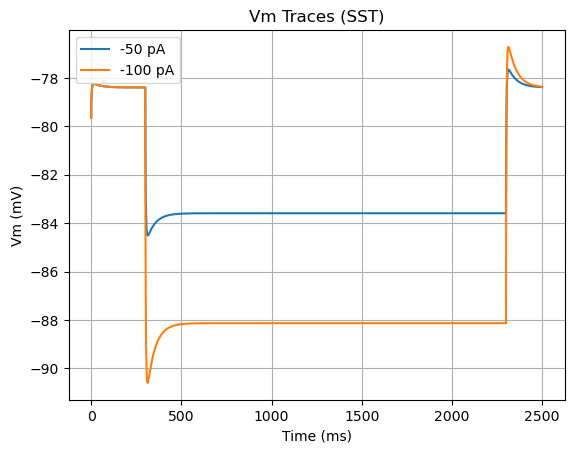

(<matplotlib.legend.Legend at 0x7fbe4332d310>, None, None)

In [ ]:
# Simulation parameters
sim_params = {
    'stim_amp': -0.1,
    'stim_delay': 300,
    'stim_dur': 1000,
    'h_tstop': 1500,
    'h_dt': 0.025
    }
# Currents injected for each sim
sim_amps = [-50,-100]

cell = build_cell.simple_build_cell(soma_diam_multiplier = 1)
looped_records = run_sim.looped_current_injection(cell,sim_params,sim_amps)
print(looped_records['I'][-50].keys())

# Analyze and plot each run
for amp in sim_amps:
    print(f"{amp} pA spike frequency = {looped_records['F'][amp]:.2f} Hz")
    if amp <0:
        # print('Desired Properties:       R_in=98.9, tau1=5.9, tau2=??.?, sag_ratio=0.960, V_rest=-71.25')
        print(f"{ACTPassiveModule.compute_gpp(looped_records['V'][amp], h.dt, sim_params['stim_delay'], sim_params['stim_delay']+sim_params['stim_dur']-10, amp/1000)}\n")
    plt.plot(looped_records['T'][amp], looped_records['V'][amp], label=f"{amp} pA")
    
# Plot parameters
plt.xlabel("Time (ms)"), plt.ylabel("Vm (mV)"), plt.title(f"Vm Traces ({cell_name})")
# plt.xlim(250,800)
# plt.ylim(-80,40)
plt.legend(),plt.grid(),plt.show()
